# SUMMARY

**Stack**: PyTorch, SkLearn, Pandas, seaborn, numpy
**Description**: Given a function with unknown coefficients and data. Find the coefficients of this function
* Pre-selection of several coefficients to bypass local minima
* Final selection of all coefficients

# Test Task

## Импорт и установка значений глобальных переменных

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from torch.optim.lr_scheduler import CosineAnnealingLR

PATH_TO_DATA = "/kaggle/input/unosoft-data"
PATH_TO_SAVE = "/kaggle/working"
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

 ## Анализ данных

<Axes: xlabel='number', ylabel='target'>

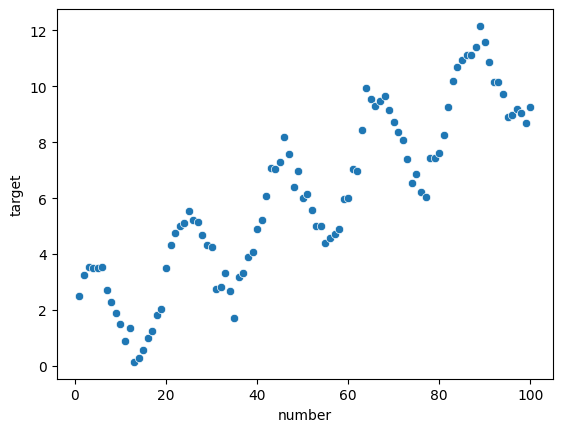

In [2]:
train_data = pd.read_csv(os.path.join(PATH_TO_DATA, "train.csv"))
test_data = pd.read_csv(os.path.join(PATH_TO_DATA, "test.csv"))
train_data.columns = ["number", "target"]
test_data.columns = ["number"]

numpy_train_data = np.array(train_data["number"]).reshape(-1, 1)
sns.scatterplot(data=train_data, x="number", y="target")

## Подбор коэффициентов "b" и "c" с помощью линейной регрессии

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


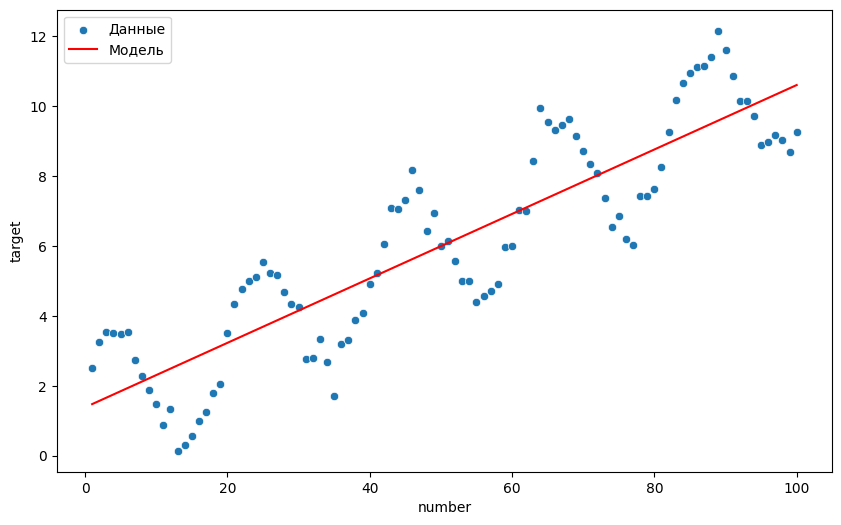

In [3]:
reg = LinearRegression()
reg.fit(numpy_train_data, train_data["target"])
x_points = np.linspace(1, 100, 2).reshape(-1, 1)
y_points = reg.predict(x_points)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_data, x="number", y="target", label='Данные')
sns.lineplot(x=x_points.flatten(), y=y_points.flatten(), color="red", label='Модель')
b = reg.coef_[0]
c = reg.intercept_

## Обучение

In [4]:
class SineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0))
        self.b = nn.Parameter(torch.tensor(b))
        self.c = nn.Parameter(torch.tensor(c))
        self.omega = nn.Parameter(torch.tensor(0.1))
        self.fi = nn.Parameter(torch.tensor(0.1))

    def forward(self, k):
        return self.a * torch.sin(self.omega * k + self.fi) + self.b * k + self.c

In [5]:
def warmup_lr_scheduler(optimizer, warmup_epochs, base_lr, epoch):
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

k_train = torch.tensor(train_data["number"]).float().unsqueeze(1)
x_train = torch.tensor(train_data["target"]).float().unsqueeze(1)
k_test = torch.tensor(test_data["number"]).float().unsqueeze(1)

warmup_epochs = 500
num_epochs = 5000
criterion = nn.MSELoss()

model = SineModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.07)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs-warmup_epochs)
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(k_train)
    loss = criterion(outputs, x_train)
    loss.backward()
    optimizer.step()
    if epoch >= warmup_epochs:
        scheduler.step()

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')
    
a = model.a.item()
b = model.b.item()
c = model.c.item()
omega = model.omega.item()
fi = model.fi.item()

with torch.no_grad():
    outputs = model(k_test)
    test_data["target"] = outputs
    test_data.columns = ["k", "x"]
    test_data.to_csv(os.path.join(PATH_TO_SAVE, "pred.csv"), sep=',', index=False, encoding='utf-8')
    
print(f"Найденные параметры: a={a:.3f}, b={b:.3f}, c={c:.3f}, omega={omega:.3f}, fi={fi:.3f}")

Epoch 0, Loss: 2.593326
Epoch 1000, Loss: 0.120384
Epoch 2000, Loss: 0.109288
Epoch 3000, Loss: 0.105475
Epoch 4000, Loss: 0.105466
Найденные параметры: a=2.007, b=0.099, c=1.042, omega=-0.301, fi=2.687


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='number', ylabel='target'>

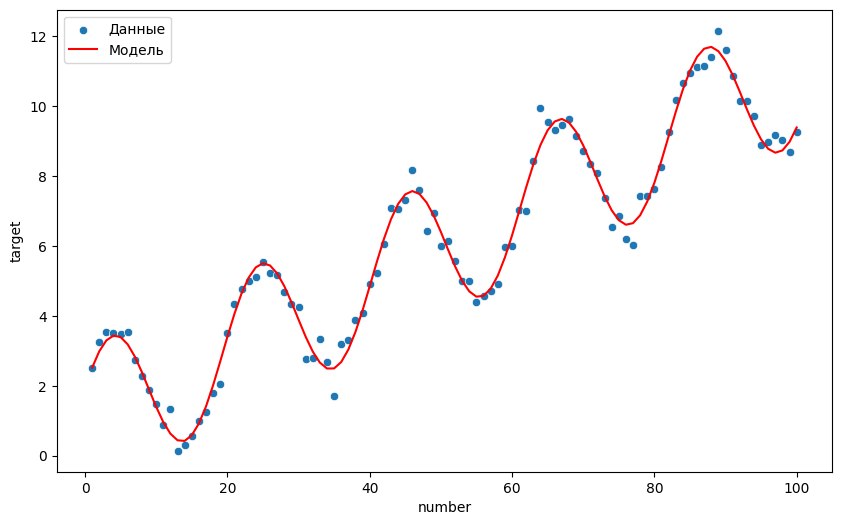

In [6]:
k_coords = np.linspace(1, 100, num=100)
with torch.no_grad():
    inputs = torch.tensor(k_coords).float().unsqueeze(1)
    x_coords = model(inputs).numpy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_data, x="number", y="target", label='Данные')
sns.lineplot(x=k_coords.flatten(), y=x_coords.flatten(), color="red", label='Модель')